1. Conv2D แปลงรูปจาก 28x28x1 เป็น 26x26x32 ยังไง
2. ทำไม ConvNet ถึงได้ 3D
3. ใน Conv2D , 1 Kernal มี weight เหมือนกันทั้ง Kernal ไหม

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [62]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers
from keras import models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

val_img = train_images[40000:]
val_labels = train_labels[40000:]
train_images = train_images[:40000]
train_labels = train_labels[:40000]

model = models.Sequential()
model.add(layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


model.compile(optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=5, batch_size=64,validation_data=(val_img,val_labels))


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9089 - loss: 0.2956 - val_accuracy: 0.9726 - val_loss: 0.0900
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9752 - loss: 0.0793 - val_accuracy: 0.9783 - val_loss: 0.0708
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9834 - loss: 0.0527 - val_accuracy: 0.9816 - val_loss: 0.0576
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9880 - loss: 0.0390 - val_accuracy: 0.9825 - val_loss: 0.0607
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.9853 - val_loss: 0.0519


In [63]:
test_loss, test_acc = model.evaluate(test_images, test_labels) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - accuracy: 0.9865 - loss: 0.0397


In [64]:
def plot(history,name="") :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(15,7))
    
    plt.subplot(1,2,1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1,2,2)
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
    print(f"min val_loss : {min(val_loss)}")
    print(f"max val_acc : {max(val_accuracy)}")
    print(f"Latest val_loss : {val_loss[len(val_loss)-1]}")
    print(f"Latest val_acc : {val_accuracy[len(val_accuracy)-1]}")

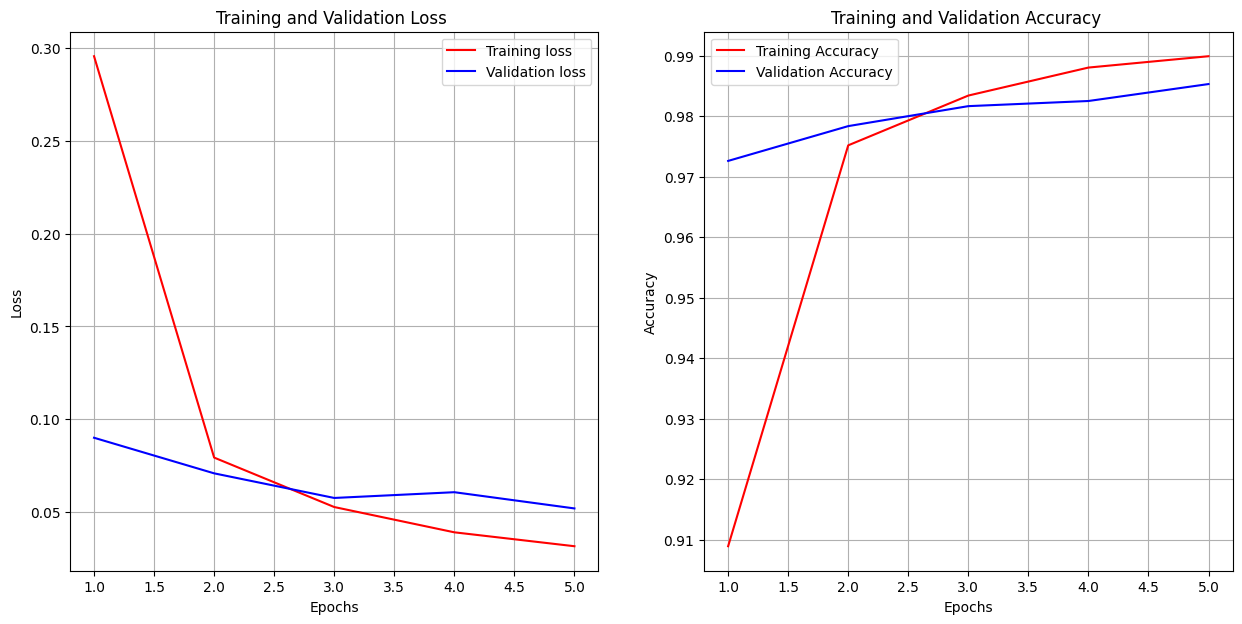

min val_loss : 0.05191643536090851
max val_acc : 0.9853000044822693
Latest val_loss : 0.05191643536090851
Latest val_acc : 0.9853000044822693
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - accuracy: 0.9865 - loss: 0.0397
Evaluate Loss : 0.03967324644327164 , Evaluate Acc : 0.9865000247955322


In [65]:
plot(history)
loss , acc = model.evaluate(test_images,test_labels)
print(f"Evaluate Loss : {loss} , Evaluate Acc : {acc}")

In [66]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 3, 3, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,390 (259.34 KB)

 Trainable params: 33,194 (129.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,196 (129.68 KB)